# STEVEN OSTUNI - DATA  601

Note: For the cell above, feel free to use the markdown code from the class Jupyter Notebook and modify it with your student information.

## DATA 601 - Fall 2025
### Homework Assignment 6

#### Due-date: Monday 12/8/2025 midnight.
The excercises in this homework provide instruction on what to do. Feel free to add as many code or markdown cells as you need. The main objective of this homework is to train a classification algorithm and predict a target feature. In this case you will have two datasets to pick from, the wine.csv or heart.csv which can be found in the input_data folder. in both datasets you will be predicting a categorical feature or "class". As discussed in class, the classification models steps (e.g., train, test, calculate metrics, etc)) discussed in class are the same here.

HW6 Datasets Objective:
__ONLY PICK ONE FOR THE HOMEWORK 6__

- Wine Dataset: Target feature: "wine_class"
- Heart Dataset: Target feature: "target"

# Question 1 (5 Points)
Load dataset use exploratory data analysis functions we discussed in class as you see fit but make sure to explore the target feature.

In [188]:
import pandas as pd
from sklearn import svm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

In [189]:
wine_df = pd.read_csv("wine.csv")

class0_count = len(wine_df[wine_df["wine_class"] == 0])
class1_count = len(wine_df[wine_df["wine_class"] == 1])
print("Class 0: " + str(class0_count) + " Class 1: " + str(class1_count) + "\n")

print("INFO: ")
wine_df.info()
print("\n\nDESCRIBE: \n" + str(wine_df.describe()) + "\n")
print("\nHEAD: \n" + str(wine_df.head()))

Class 0: 59 Class 1: 71

INFO: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       130 non-null    float64
 1   malic_acid                    130 non-null    float64
 2   ash                           130 non-null    float64
 3   alcalinity_of_ash             130 non-null    float64
 4   magnesium                     130 non-null    float64
 5   total_phenols                 130 non-null    float64
 6   flavanoids                    130 non-null    float64
 7   nonflavanoid_phenols          130 non-null    float64
 8   proanthocyanins               130 non-null    float64
 9   color_intensity               130 non-null    float64
 10  hue                           130 non-null    float64
 11  od280/od315_of_diluted_wines  130 non-null    float64
 12  proline                       13

# Question 2 (5 Points)
Split the data into training (80%) and testing (20%).

In [190]:
df_testing = wine_df.sample(frac=0.2).copy()
df_training = wine_df.drop(df_testing.index)

training_X = df_training.drop(columns=["wine_class"])
training_Y = df_training["wine_class"].copy()
testing_X = df_testing.drop(columns=["wine_class"])
testing_Y_check = df_testing["wine_class"].copy() # Will be used to check the predicted classes' accuracy.

# Question 3 (10 Points)
Use SVM algorithm to predict the class and calculate metrics: Confustion Matrix, Accuracy, Sensitivity and Specificity.

In [191]:
clf = svm.SVC()
clf.fit(training_X, training_Y)

y_predict = clf.predict(testing_X)
cm1 = confusion_matrix(testing_Y_check, y_predict)
print('Confusion Matrix (SVM): \n', cm1)
# TruPos, FalNeg
# FalPos, TrueNeg

total1 = sum(sum(cm1)) #First sum adds the tuples together. Second some adds the contents of the resulting tuple.
accuracy1 = (cm1[0,0] + cm1[1,1]) / total1 # accurate guesses/total
print("Accuracy: " + str(accuracy1))

sensitivity1 = cm1[0,0]/(cm1[0,0] + cm1[0,1]) # accurate true predictions / actual true cases
print("Sensitivity: " + str(sensitivity1))

specificity1 = cm1[1,1]/(cm1[1,0] + cm1[1,1]) # accurate false predictions / actual false cases
print("Specificity: " + str(specificity1))

Confusion Matrix (SVM): 
 [[ 9  2]
 [ 2 13]]
Accuracy: 0.8461538461538461
Sensitivity: 0.8181818181818182
Specificity: 0.8666666666666667


In [192]:
# I tried artificially inflating the dataset to see if it improved the results, but it didn't.

df_testing_big = df_testing.sample(frac=50, replace=True).reset_index(drop=True)
df_training_big = df_training.sample(frac=50, replace=True).reset_index(drop=True)

training_X = df_training_big.drop(columns=["wine_class"])
training_Y = df_training_big["wine_class"].copy()
testing_X = df_testing_big.drop(columns=["wine_class"])
testing_Y_check = df_testing_big["wine_class"].copy()

clf = svm.SVC()
clf.fit(training_X, training_Y)

y_predict = clf.predict(testing_X)
cm1 = confusion_matrix(testing_Y_check, y_predict)
print('Confusion Matrix (SVM): \n', cm1)

total1 = sum(sum(cm1))
accuracy1 = (cm1[0,0] + cm1[1,1]) / total1
print("Accuracy: " + str(accuracy1))

sensitivity1 = cm1[0,0]/(cm1[0,0] + cm1[0,1])
print("Sensitivity: " + str(sensitivity1))

specificity1 = cm1[1,1]/(cm1[1,0] + cm1[1,1])
print("Specificity: " + str(specificity1))

Confusion Matrix (SVM): 
 [[460 102]
 [ 91 647]]
Accuracy: 0.8515384615384616
Sensitivity: 0.8185053380782918
Specificity: 0.8766937669376694


# Question 4 (10 Points)
Use a random forest classifier to predict the class and calculate metrics: Confustion Matrix, Accuracy, Sensitivity and Specificity.

In [193]:
clf = RandomForestClassifier(max_depth=2, random_state=0)
clf.fit(training_X, training_Y)

y_predict = clf.predict(testing_X)

cm2 = confusion_matrix(testing_Y_check, y_predict)
print('Confusion Matrix (Random Forest): \n', cm2)

total2 = sum(sum(cm2))
accuracy2 = (cm2[0,0] + cm2[1,1]) / total1
print("Accuracy: " + str(accuracy2))
sensitivity2 = cm2[0,0] / (cm2[0,0] + cm2[0,1])
print("Sensitivity: " + str(sensitivity2))
specificity2 = cm2[1,1] / (cm2[1,0] + cm2[1,1])
print("Specificity: " + str(specificity2))

Confusion Matrix (Random Forest): 
 [[562   0]
 [ 47 691]]
Accuracy: 0.9638461538461538
Sensitivity: 1.0
Specificity: 0.9363143631436315


# Question 5 (10 Points)
How many datapoints do we have in this dataset? Provide thoughts and comments on the size of this dataset on at least two of the following:  
- Which of the classification models above performed better?
- What are some challenges of the size of this dataset?
- Would you feel comfortable with using this dataset for predictions?
- What could be some things that you could do for improving the outputs and performance of the models? This could include steps during the data collection, cleaning/preparation/transformation, testing, training steps and/or model deployment.

-We have 130 datapoints in this dataset, 104 of which we used in the training data.

-This is a pretty small dataset, which carries the risk of overfitting and of covering only a limited range of possible cases.

-I don't think I'd feel comfortable using this dataset in predictions, unless the content I was predicting strongly resembled that of the dataset.

-To improve this data's output, I tried making a version that was 50 times bigger and randomly sampled from the same values. (I duplicated the training and testing sets separately, so that it still wouldn't know the testing answers.) I ran it a few times but on average it seems like its results were about the same quality as the small version's. I don't think this would be the case with more starting data. It seems like there's simply not enough in the training set to fully prepare it for the testing set's content. The data seems pretty clean, but I noticed the Class 0 to Class 1 ratio is 59:71. Adding some more class 0 values to make it even would help balance things. Though the data's small enough already that I wouldn't want to remove any Class 1 datapoints.

# Question 6 (15 Points)

We have the toy dataset "diamonds" loaded from SNS. The dataset is related to diamond characteristics. Please comment on the following questions. 
1. Comment on which features could we predict and which features could be potentially used for training?
2. What could be an appropriate model to use?
3. Using the sns.pairplot function, visually identify potential features where a linear regression model could be used to predict.
4. Use the linear regression model to predict one of the features.
5. Comment on the applicability of the linear regression. What could be done to improve the modeling and prediction?

In [194]:
import seaborn as sns
diamonds = sns.load_dataset("diamonds")
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


1.) We could predict price from the other atributes of a diamond. I don't think any of the other values could be predicted. I suspect the carat and size_dimension (x * y * z) would be the most useful features for training -  they're the numerical qualities that people associate with expensive diamonds. Cut seems relevant too, though it's not usable in this form. The different values have a clear rank, so they might be convertable into integers. But it's not clear what the quality different between each is, so each value might be better converted into a boolean column. I'll ignore cut for now. I'll also leave out color- it's likely that some diamond colors are rarer or pricier, there's no clear way to rank them.

2.) The SVM and random forest models are both for sharp categorizations rather than extrapolating a value from a continous range. For this case, a linear regression model is the best choice.

In [195]:
# 3.)
from pandas.api.types import is_numeric_dtype

#The outliers were making some of the plots hard to read, so I'm going to remove them.
#Adapted From: https://www.geeksforgeeks.org/python/how-to-use-pandas-filter-with-iqr/

# Removing the outliers - just for the pairplots
def removeOutliers(data, col):
    Q3 = np.quantile(data[col], 0.75)
    Q1 = np.quantile(data[col], 0.25)
    IQR = Q3 - Q1
    
    global outlier_free_list
    global filtered_data

    lower_range = Q1 - 1.5 * IQR
    upper_range = Q3 + 1.5 * IQR
    outlier_free_list = [x for x in data[col] if (
        (x > lower_range) & (x < upper_range))]
    
    filtered_data = data.loc[data[col].isin(outlier_free_list)]


for i in diamonds.columns:
    if is_numeric_dtype(diamonds[i]):
        if i == diamonds.columns[0]:
            removeOutliers(diamonds, i)
        else:
            removeOutliers(filtered_data, i)

# Assigning filtered data back to our original variable
diamonds_filtered = filtered_data

print(len(diamonds))
print(len(diamonds_filtered))

53940
46171


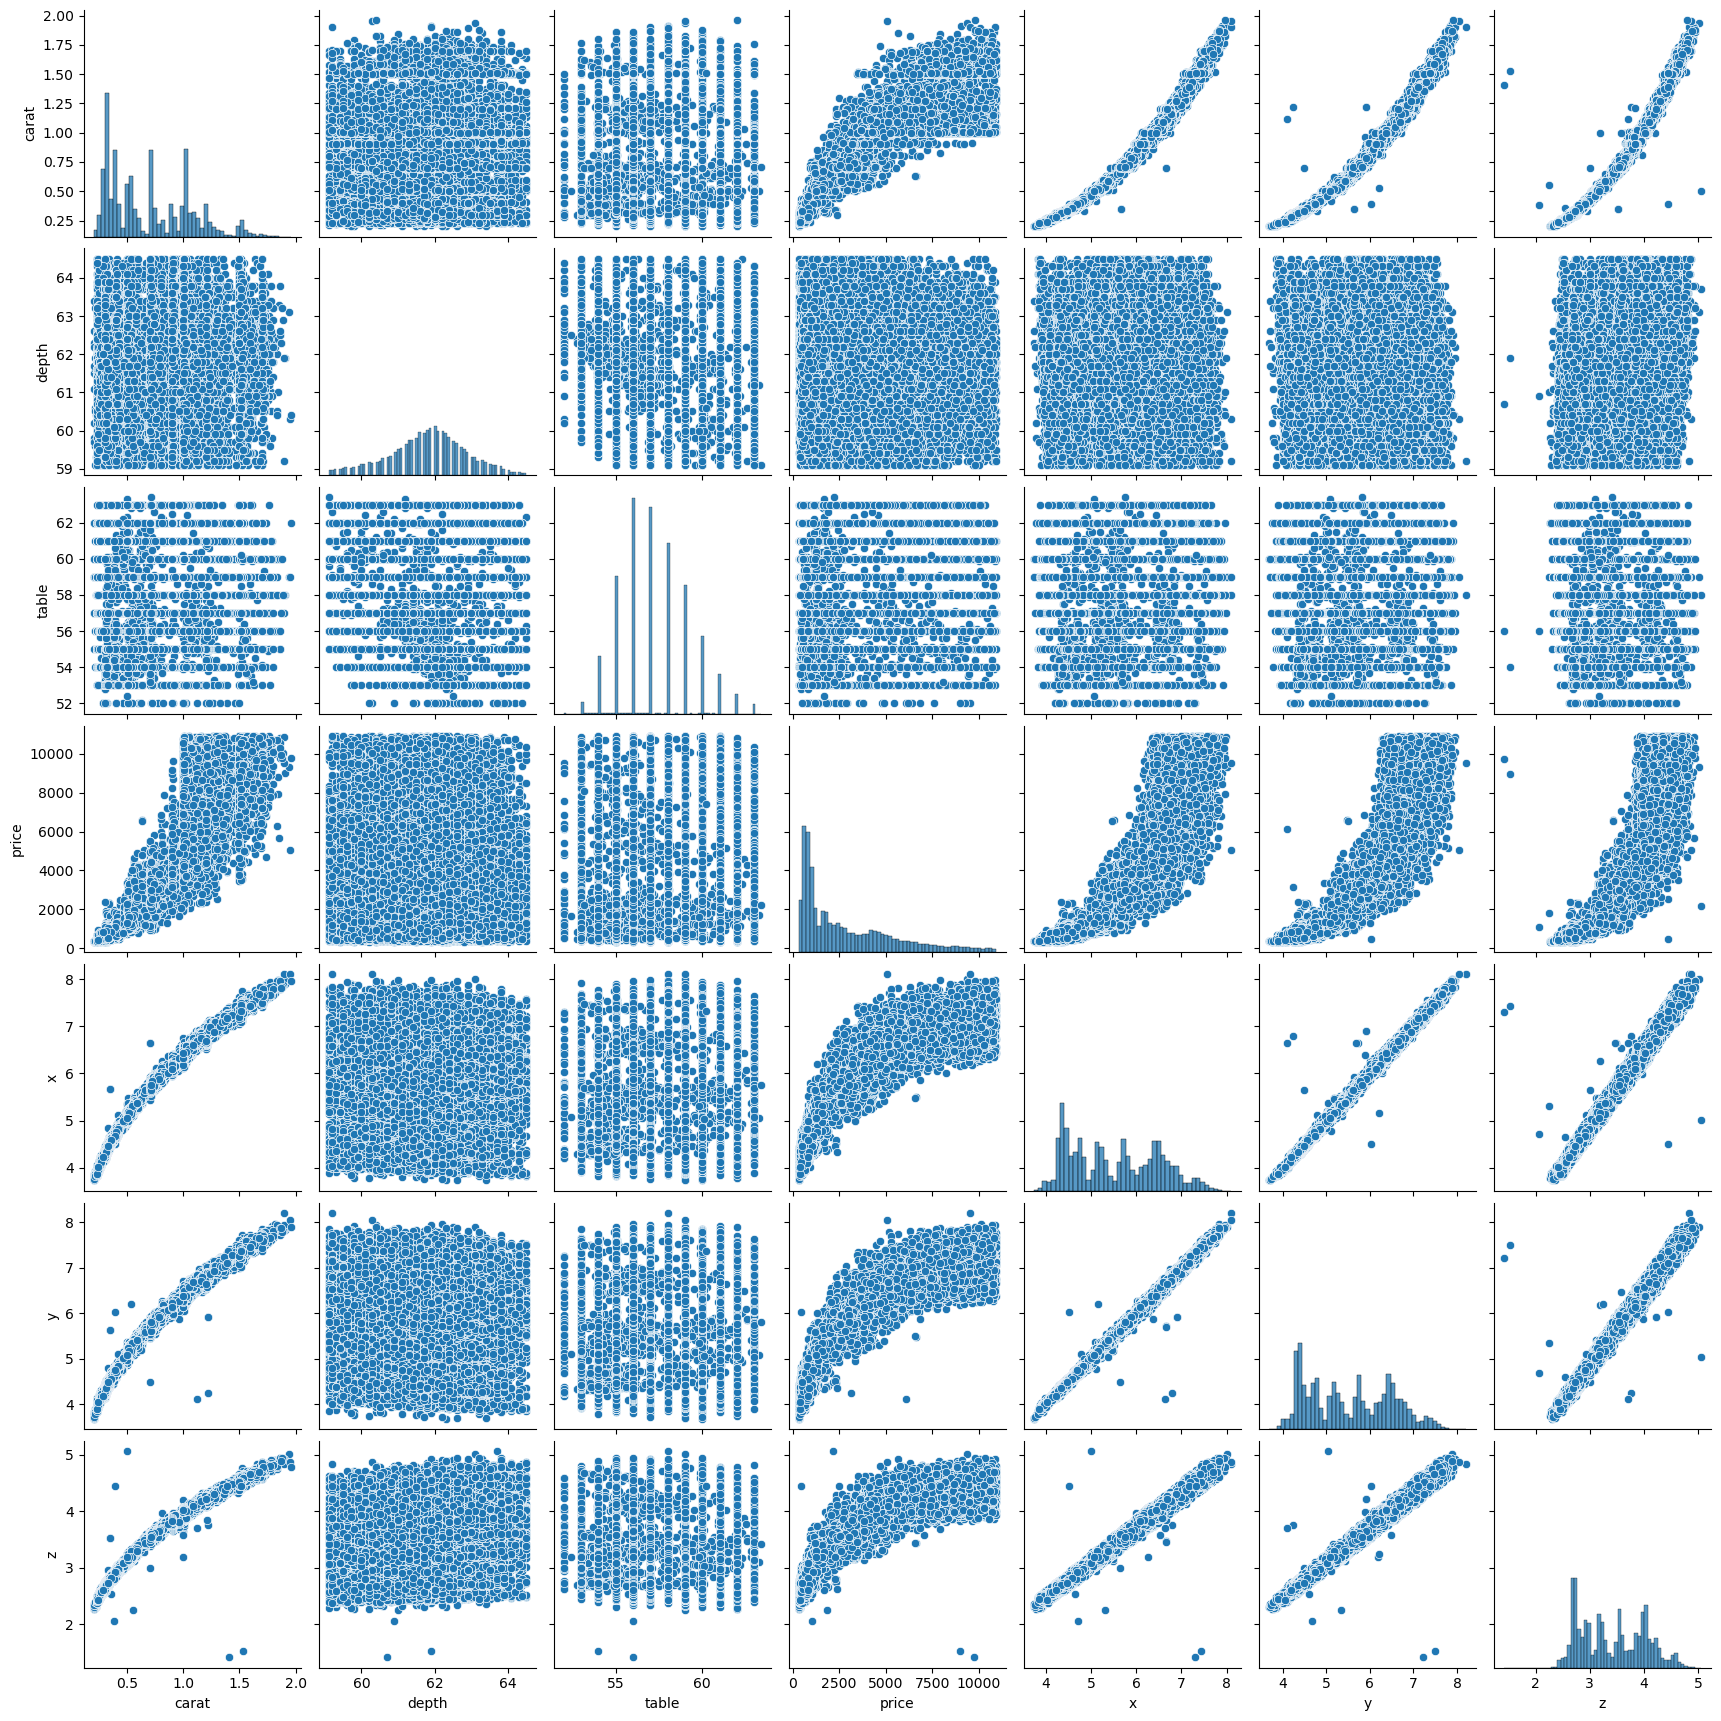

In [196]:
import matplotlib.pyplot as plt
sns.pairplot(diamonds_filtered.sample(frac=1)) # For some reason, this is faster than running the nonsampled data
plt.show()

In [197]:
print("Coefficients:\n")
for i in range(0, len(X.columns)):
    print(str(i) + ": " + str(X.columns[i]) + ": " + str(simple_lin_model.coef_[i]))

Coefficients:

0: carat: 8162.650649090073
1: x: 290.3014037614199
2: y: -1336.093039509192
3: z: -772.2986274258574
4: vol_box: 17.220570050282305
5: vol_ellipsoid: 9.016669393970403
6: cut_Ideal: 593.4026449689554
7: cut_Premium: 206.38270570027748
8: cut_VeryGood: 361.6687938471579
9: cut_Good: -8.457503775886668
10: cut_Fair: -1152.9966407404952
11: color_E: 479.5250970075878
12: color_I: -563.2536700406353
13: color_J: -1388.057619858534
14: color_H: -178.5003059359493
15: color_F: 543.4232422531343
16: color_G: 502.1419862228177
17: color_D: 604.721270351576


3.) From the plot, carat, x, y, and z have the strongest correlations. I'll use them for my linear regression model.

In [198]:
#4.) Using linear regression to predict PRICE

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import numpy as np

X = pd.DataFrame(np.c_[diamonds['carat'],diamonds['x'], diamonds['y'],diamonds['z']], columns = ['carat','x','y','z'])

Y = diamonds['price']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=17)

simple_lin_model = LinearRegression()
simple_lin_model.fit(X_train, Y_train)

y_test_predict = simple_lin_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(Y_test, y_test_predict))
r2 = r2_score(Y_test, y_test_predict)
print('RMSE (root mean squared error) is ' + str(rmse))
print('R2 score is ' + str(r2))
# Getting the data range to check how good or bad our RMSE is.
range_price = diamonds['price'].max() - diamonds['price'].min()
print("Diamond price range size: " + str(range_price))

RMSE (root mean squared error) is 1538.6538929175924
R2 score is 0.8538031682118433
Diamond price range size: 18497


5.) It seems like the linear regression is reasonably applicable. The RMSE is $1538.65, which seems like a huge size for an average error magnitude.
Measured against the value range of 18500, this is better but still not amazing- its's about 1/12 of the overall range.

That said, we're basically using only two dimensions: carat and size, where size is broken into x,y,z components since shape is unspecified. There's plenty more that goes into a diamond price.

To improve our model, first I would like the create a better evaluation of the shape. I don't think linear regression can establish a relationship between x,y,z and scale, but it seems likely that the relationship to the price is a matter of diamond volume. I'll create two different volume columns- one will be a box volume, and the other a rounded ellipsoid volume of the same dimensions.

I'll also create one-hot bool columns for each possible value of cut and color. It seems like they both should affect the price.
I got curious so, I tried my new version below.

In [199]:
print(diamonds['cut'].unique()) # Unique Values:  'Ideal', 'Premium', 'Very Good', 'Good', 'Fair'
print(diamonds['color'].unique()) # Unique Values: 'E', 'I', 'J', 'H', 'F', 'G', 'D'

['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Categories (7, object): ['D', 'E', 'F', 'G', 'H', 'I', 'J']


In [200]:
#TAKE 2:
import math

dia2 = diamonds.copy()

dia2['vol_box'] = dia2['x'] * dia2['y'] * dia2['z']
dia2['vol_ellipsoid'] = dia2['vol_box'] * math.pi / 6 # Adapted from the equation for ellipsoid volume:
#https://www.geeksforgeeks.org/maths/how-to-calculate-the-volume-of-an-ellipsoid/

# One-hot bool columns for cut
dia2['cut_Ideal'] = (dia2['cut'] == 'Ideal').astype(int)
dia2['cut_Premium'] = (dia2['cut'] == 'Premium').astype(int)
dia2['cut_VeryGood'] = (dia2['cut'] == 'Very Good').astype(int)
dia2['cut_Good'] = (dia2['cut'] == 'Good').astype(int)
dia2['cut_Fair'] = (dia2['cut'] == 'Fair').astype(int)

# One-hot bool columns for color
dia2['color_E'] = (dia2['color'] == 'E').astype(int)
dia2['color_I'] = (dia2['color'] == 'I').astype(int)
dia2['color_J'] = (dia2['color'] == 'J').astype(int)
dia2['color_H'] = (dia2['color'] == 'H').astype(int)
dia2['color_F'] = (dia2['color'] == 'F').astype(int)
dia2['color_G'] = (dia2['color'] == 'G').astype(int)
dia2['color_D'] = (dia2['color'] == 'D').astype(int)

print(dia2.head())

   carat      cut color clarity  depth  table  price     x     y     z  ...  \
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43  ...   
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31  ...   
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31  ...   
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63  ...   
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75  ...   

   cut_VeryGood  cut_Good  cut_Fair  color_E  color_I  color_J  color_H  \
0             0         0         0        1        0        0        0   
1             0         0         0        1        0        0        0   
2             0         1         0        1        0        0        0   
3             0         0         0        0        1        0        0   
4             0         1         0        0        0        1        0   

   color_F  color_G  color_D  
0        0        0        0  
1        0  

In [201]:
columns_names_list = ['carat','x','y','z','vol_box','vol_ellipsoid','cut_Ideal','cut_Premium','cut_VeryGood','cut_Good','cut_Fair', \
'color_E', 'color_I','color_J','color_H', 'color_F','color_G','color_D']

X = dia2[columns_names_list].copy()

Y = dia2['price']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=17)

simple_lin_model = LinearRegression()
simple_lin_model.fit(X_train, Y_train)

y_test_predict = simple_lin_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(Y_test, y_test_predict))
r2 = r2_score(Y_test, y_test_predict)
print('RMSE (root mean squared error) is ' + str(rmse))
print('R2 score is ' + str(r2))
# Getting the data range to check how good or bad our RMSE is.
range_price = dia2['price'].max() - dia2['price'].min()
print("Diamond price range size: " + str(range_price))

#The results are still not amazing, but it is an improvement!

RMSE (root mean squared error) is 1427.8036984619964
R2 score is 0.8741094629054523
Diamond price range size: 18497


In [233]:
#Let's see how good my guesses were
print("Coefficients and Correlations:\n")
for i in range(0, len(X.columns)):
    corr = dia2['price'].corr(dia2[X.columns[i]])
    print(str(i) + ": " + str(X.columns[i]) + "\nCOEFF = " + str(round(simple_lin_model.coef_[i],1)) + \
          "\nCORR = " + str(round(corr,2)) + "\n")

Coefficients and Correlations:

0: carat
COEFF = 8162.7
CORR = 0.92

1: x
COEFF = 290.3
CORR = 0.88

2: y
COEFF = -1336.1
CORR = 0.87

3: z
COEFF = -772.3
CORR = 0.86

4: vol_box
COEFF = 17.2
CORR = 0.9

5: vol_ellipsoid
COEFF = 9.0
CORR = 0.9

6: cut_Ideal
COEFF = 593.4
CORR = -0.1

7: cut_Premium
COEFF = 206.4
CORR = 0.1

8: cut_VeryGood
COEFF = 361.7
CORR = 0.01

9: cut_Good
COEFF = -8.5
CORR = -0.0

10: cut_Fair
COEFF = -1153.0
CORR = 0.02

11: color_E
COEFF = 479.5
CORR = -0.1

12: color_I
COEFF = -563.3
CORR = 0.1

13: color_J
COEFF = -1388.1
CORR = 0.08

14: color_H
COEFF = -178.5
CORR = 0.06

15: color_F
COEFF = 543.4
CORR = -0.02

16: color_G
COEFF = 502.1
CORR = 0.01

17: color_D
COEFF = 604.7
CORR = -0.07



# NOTEBOOK END